Author : Khadija Jumani

Netflix-Dataset-Analysis


This project performs Exploratory Data Analysis (EDA) on the Netflix Titles Dataset from Kaggle.
The goal is to explore patterns, trends, and insights about the types of content available on Netflix — including movies and TV shows, their release years, genres, countries of origin, and more.

In [3]:
# 📺 Netflix Dataset Analysis
# ------------------------------------------------------------
# This notebook performs EDA on the Netflix Titles dataset
# Source: https://www.kaggle.com/datasets/shivamb/netflix-shows
# ------------------------------------------------------------

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure display and style
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
%matplotlib inline

# ------------------------------------------------------------
# 1️⃣ Load Dataset
# ------------------------------------------------------------
df = pd.read_csv('C:\\Users\\PMYLS\\Desktop\\github work\\netflix_titles.csv')
print("Dataset loaded successfully ✅")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully ✅
Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# ------------------------------------------------------------
# 2️⃣ Basic Information and Data Overview
# ------------------------------------------------------------
df.info()
df.describe(include='all').T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values per column:
director      2634
country        831
cast           825
date_added      10
rating           4
duration         3
dtype: int64


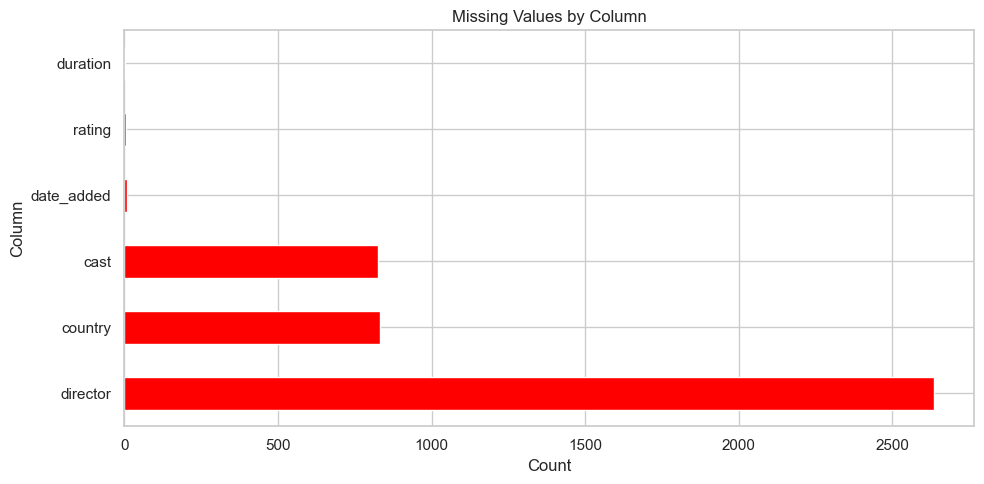

In [5]:
# ------------------------------------------------------------
# 3️⃣ Checking for Missing Values
# ------------------------------------------------------------
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values per column:")
print(missing[missing > 0])

plt.figure(figsize=(10,5))
missing[missing > 0].plot(kind='barh', color='red')
plt.title("Missing Values by Column")
plt.xlabel("Count")
plt.ylabel("Column")
plt.tight_layout()
plt.show()


In [6]:
# ------------------------------------------------------------
# 4️⃣ Data Cleaning
# ------------------------------------------------------------
# Drop duplicates if any
df.drop_duplicates(inplace=True)

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year from 'date_added' if needed
df['year_added'] = df['date_added'].dt.year

print("After cleaning, dataset shape:", df.shape)


After cleaning, dataset shape: (8807, 13)


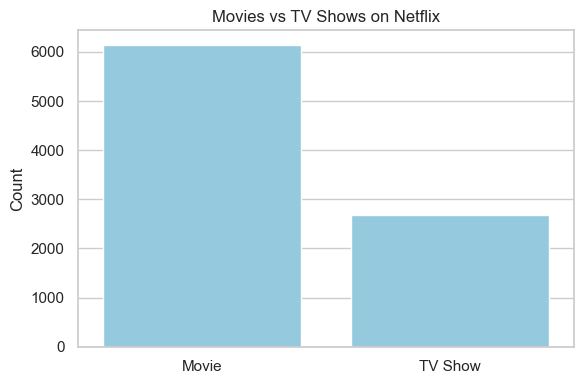

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [10]:
# ------------------------------------------------------------
# 5️⃣ Content Type Distribution
# ------------------------------------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df, color='skyblue')  # single color
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("")
plt.ylabel("Count")
plt.tight_layout()

# Create folder if it doesn't exist
import os
os.makedirs('../outputs', exist_ok=True)


plt.savefig('../outputs/type_distribution.png')
plt.show()

df['type'].value_counts()


C:\Users\PMYLS\AppData\Local\Temp\ipykernel_17080\2678903648.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="coolwarm")


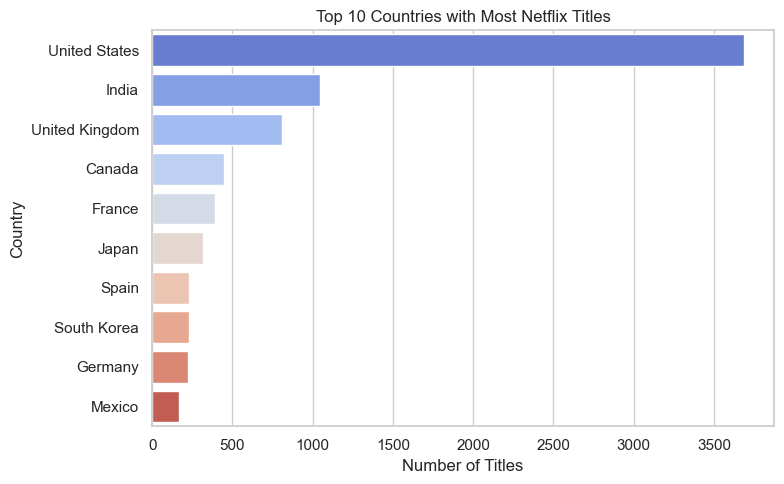

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

In [11]:
# ------------------------------------------------------------
# 6️⃣ Top 10 Countries with Most Content
# ------------------------------------------------------------
country_split = df['country'].dropna().str.split(',').explode().str.strip()
top_countries = country_split.value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="coolwarm")
plt.title("Top 10 Countries with Most Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig('../outputs/top_countries.png')
plt.show()

top_countries


C:\Users\PMYLS\AppData\Local\Temp\ipykernel_17080\355848542.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette="crest")


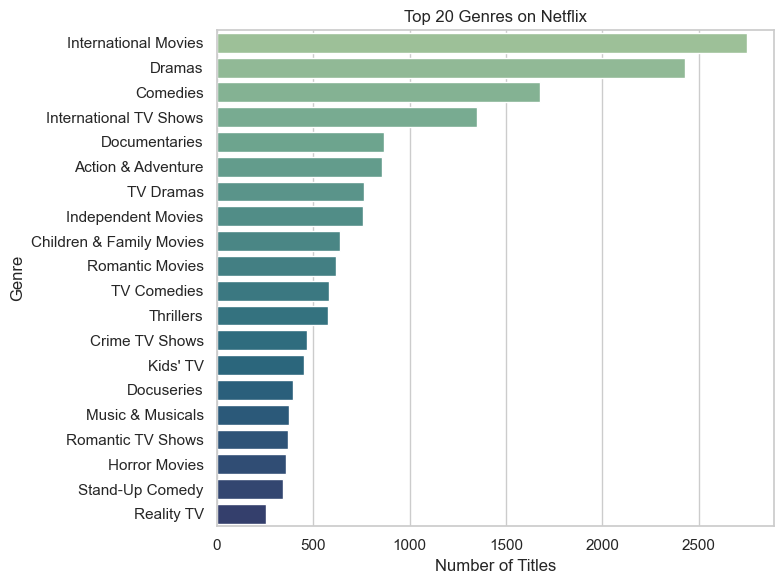

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Music & Musicals             375
Romantic TV Shows            370
Horror Movies                357
Stand-Up Comedy              343
Reality TV                   255
Name: count, dtype: int64

In [12]:
# ------------------------------------------------------------
# 8️⃣ Most Common Genres (Top 20)
# ------------------------------------------------------------
genres = df['listed_in'].dropna().str.split(',').explode().str.strip()
top_genres = genres.value_counts().head(20)

plt.figure(figsize=(8,6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="crest")
plt.title("Top 20 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig('../outputs/top_genres.png')
plt.show()

top_genres

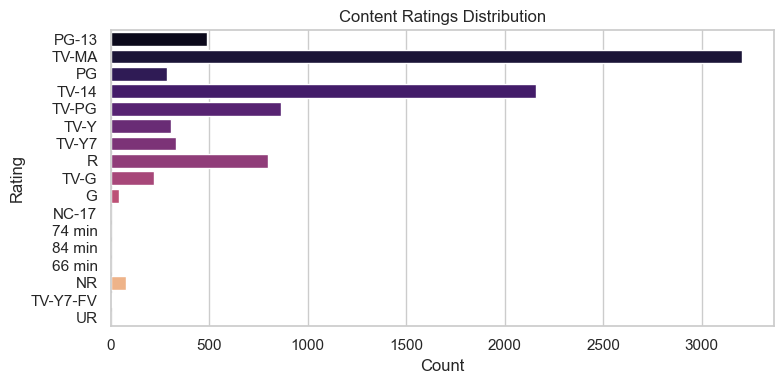

In [13]:
# ------------------------------------------------------------
# 9️⃣ Ratings Distribution
# ------------------------------------------------------------
plt.figure(figsize=(8,4))
sns.countplot(y='rating', hue='rating', data=df, palette='magma', legend=False)
plt.title("Content Ratings Distribution")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.tight_layout()
plt.savefig('../outputs/ratings_distribution.png')
plt.show()

In [14]:
# ------------------------------------------------------------
# 🔟 Simple Text Classification (Optional Mini Model)
# ------------------------------------------------------------
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

df_model = df.dropna(subset=['description', 'type'])
X = df_model['description']
y = df_model['type']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

vec = CountVectorizer(max_features=2000, stop_words='english')
Xtr = vec.fit_transform(X_train)
Xte = vec.transform(X_test)

model = MultinomialNB()
model.fit(Xtr, y_train)
preds = model.predict(Xte)

print("📊 Classification Report:\n")
print(classification_report(y_test, preds))

# ------------------------------------------------------------
# 🔚 Conclusions
# ------------------------------------------------------------
print("""
✅ Netflix Dataset EDA Summary:
- Movies are more numerous than TV Shows.
- US, India, and UK produce the highest number of titles.
- Most content released after 2015.
- Top genres: International Movies, Dramas, and Comedies.
""")

📊 Classification Report:

              precision    recall  f1-score   support

       Movie       0.78      0.82      0.80      1227
     TV Show       0.53      0.46      0.49       535

    accuracy                           0.71      1762
   macro avg       0.65      0.64      0.65      1762
weighted avg       0.70      0.71      0.71      1762


✅ Netflix Dataset EDA Summary:
- Movies are more numerous than TV Shows.
- US, India, and UK produce the highest number of titles.
- Most content released after 2015.
- Top genres: International Movies, Dramas, and Comedies.

